In [130]:
import json
import numpy as np
from tqdm import tqdm
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
from scipy.optimize import least_squares
from scipy.special import erf
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales

In [131]:
index = {}

with open("../Step_2_Integration/observability_bright.json", "rb") as f:
    while True:
        pos = f.tell()
        line = f.readline()

        if not line:
            break

        s = line.strip()

        if s in (b"", b"{", b"}"):
            continue

        # key is before first colon
        key_bytes = s.split(b":", 1)[0]
        key = json.loads(key_bytes.decode())

        index[int(key)] = pos

print("nkeys:", len(index))

def load_observability_key(filename, index, key):
    key = int(key)

    with open(filename, "rb") as f:
        f.seek(index[key])
        line = f.readline().decode().strip()

    if line.endswith(","):
        line = line[:-1]

    rec = json.loads("{" + line + "}")
    return np.asarray(rec[str(key)])

nkeys: 51190


In [132]:
def generate_trail(shape, flux, x0, y0, length, theta, sigma, background=0.0):
    ny, nx = shape
    y, x = np.mgrid[0:ny, 0:nx]
    xp = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
    yp = -(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta)
    prefactor = flux / (length * 2.0 * sigma * np.sqrt(2.0 * np.pi))
    cross_trail = np.exp(-(yp ** 2) / (2.0 * sigma ** 2))
    u1 = (xp + length / 2.0) / (sigma * np.sqrt(2.0))
    u2 = (xp - length / 2.0) / (sigma * np.sqrt(2.0))
    along_trail = erf(u1) - erf(u2)
    return background + prefactor * cross_trail * along_trail


def fit_trail(image, p0, bounds=None):
    ny, nx = image.shape

    def residuals(params):
        flux, x0, y0, length, theta, sigma, background = params
        if length <= 0 or sigma <= 0 or flux < 0:
            return np.full(image.size, 1e30)
        model = generate_trail(image.shape, flux, x0, y0, length, theta, sigma, background)
        return (model - image).ravel()

    if bounds is None:
        lower = [0.0, 0.0, 0.0, 1e-6, -np.pi, 1e-3, -np.inf]
        upper = [np.inf, nx, ny, max(nx, ny), np.pi, np.inf, np.inf]
        bounds = (lower, upper)

    result = least_squares(residuals, p0, bounds=bounds)
    best_fit = {"flux": result.x[0], "x0": result.x[1], "y0": result.x[2], "length": result.x[3], "theta": result.x[4], "sigma": result.x[5], "background": result.x[6]}
    model = generate_trail(image.shape, best_fit["flux"], best_fit["x0"], best_fit["y0"], best_fit["length"], best_fit["theta"], best_fit["sigma"], best_fit["background"])
    return result, best_fit, model

In [133]:
mpcnum = 1
obs = load_observability_key("../Step_2_Integration/observability_bright.json", index, mpcnum)
print(obs.shape)
print(obs[:10])

(6263, 7)
[['243.33128' '-12.933481' '2.2607365' '2.6862247' '2411433.917859954'
  'i00768' '7.246961421394394']
 ['230.25215' '-15.6733885' '2.193429' '2.7920167' '2411565.614578704'
  'i01460' '7.265207963672594']
 ['339.79263' '-19.649696' '2.4535859' '2.9757347' '2411898.912928241'
  'b06327' '7.646977382690467']
 ['340.133' '-19.848923' '2.4063885' '2.9764988' '2411902.8112824075'
  'b06363' '7.605357276225835']
 ['340.40335' '-20.092997' '2.3588226' '2.9772534' '2411906.865460648'
  'b06387' '7.562555400081958']
 ['340.40387' '-20.09358' '2.3587186' '2.977255' '2411906.874462963'
  'b06388' '7.562460825168908']
 ['340.1122' '-22.242989' '2.1230605' '2.9808629' '2411930.759415509'
  'b06561' '7.336521860361453']
 ['50.76535' '12.331429' '1.8360833' '2.759565' '2412438.656556713'
  'i07633' '6.853665043017613']
 ['50.00687' '12.441715' '1.8578041' '2.756414' '2412442.6348993056'
  'i07647' '6.876721820241446']
 ['48.881805' '12.694613' '1.9050819' '2.7508905' '2412449.6057453705'
 

In [ ]:
fit_results = []
preds = []

for i in range(100): #loop over the images, plot and fit them!
    ra, dec, rearth, rsun, jd, plate_id, vmag = obs[i]
    preds.append([ra,dec,vmag])
    fits_path = f"./{mpcnum}/{mpcnum}_{plate_id}.fits"
    hdul = fits.open(fits_path)
    hdu = next(h for h in hdul if h.data is not None)

    raw_image = hdu.data
    
    ny, nx = raw_image.shape
    N = 3

    y0, y1 = ny // N, (N - 1) * ny // N
    x0, x1 = nx // N, (N - 1) * nx // N
    image = raw_image[y0:y1, x0:x1]


    wcs = WCS(hdu.header)

    pixscale_arcsec = np.mean(proj_plane_pixel_scales(wcs)) * 3600.0  #check this 
    sigma_arcsec = 5.0
    sigma_pix = sigma_arcsec / pixscale_arcsec

    x_pred_raw, y_pred_raw = wcs.world_to_pixel_values(float(ra), float(dec))
    x_pred = x_pred_raw - x0
    y_pred = y_pred_raw - y0    

    ny, nx = image.shape

    peak_flux = image[int(y_pred), int(x_pred)] - np.median(image) 
    length0 = sigma_pix
    flux0 = peak_flux * length0 * np.sqrt(2 * np.pi) * sigma_pix #compute a rough peak-flux based on a circular guess
    
    print(flux0)


    p0 = [
        np.max([flux0,0]),            # use my peak flux guess (or zero if negative)
        x_pred,            # x0
        y_pred,            # y0
        2.0,              # length (set to sigma_pix for now - maight change later)
        np.deg2rad(2.0),  # theta (random for now, mighth change later)
        sigma_pix,         # sigma go for roughly 5 arcsec
        np.median(image),  # background
    ]
    print(p0)

    result, best_fit, model = fit_trail(image, p0)
    resid = image - model

    #fit_ra, fit_dec = wcs.pixel_to_world_values(best_fit['x0'],best_fit['y0'])
    fit_ra, fit_dec = wcs.pixel_to_world_values(best_fit['x0'] + x0,best_fit['y0'] + y0)

    fig, axes = plt.subplots(1, 3, figsize=(24, 8), subplot_kw={"projection": wcs})
    vmin = min(np.min(image), np.min(model))
    vmax = max(np.max(image), np.max(model))
    rmax = np.max(np.abs(resid))

    im0 = axes[0].imshow(image, origin="lower", vmin=vmin, vmax=vmax)
    axes[0].set_title("Data")
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(model, origin="lower", vmin=vmin, vmax=vmax)
    axes[1].set_title("Fit")
    fig.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(resid, origin="lower", vmin=-rmax, vmax=rmax)
    axes[2].set_title("Residual")
    fig.colorbar(im2, ax=axes[2])

    for ax in axes:
        ax.scatter(x_pred, y_pred, marker="x", c="red", s=90, linewidths=2, transform=ax.get_transform("pixel"),alpha=0.1)

    plt.tight_layout()

    for ax in axes:
        ax.set_xlabel("RA")
        ax.set_ylabel("Dec")

    plt.tight_layout()
    plt.show()
    
    fit_results.append([result,best_fit,model,[fit_ra,fit_dec,best_fit['flux']]])

In [136]:
fits = np.array([f[-1] for f in fit_results]).astype(float)
preds = np.array(preds).astype(float)

In [137]:
fit_ra, fit_dec, fit_flux = fits.T
pred_ra, pred_dec, pred_mag = preds.T

dra = (fit_ra - pred_ra) * 3600.0 * np.cos(np.deg2rad(pred_dec))  # arcsec
ddec = (fit_dec - pred_dec) * 3600.0                              # arcsec

t = np.arange(len(dra))

In [138]:
fit_ra-pred_ra

array([-1.01425038e-04, -4.36706066e-04, -9.78747155e-04,  9.69812920e-04,
        1.10016970e-03,  8.17335048e-04, -8.89323673e-04, -2.31516678e-04,
       -2.60415130e-04, -2.86188019e-04, -2.03044785e-03, -3.20993448e-04,
       -4.48352457e-04, -7.87197928e-05,  4.87862587e-02,  1.97256301e-04,
        2.48441959e-04, -1.09791973e-03,  5.10654971e-04, -6.29479298e-02,
       -2.56476039e-04,  1.07785930e-03,  6.64221276e-04,  7.75443065e-04,
        9.79033589e-04,  1.37231325e-03, -9.76530545e-04, -1.87276872e-04,
        7.68156444e-04, -3.24805943e-02, -5.90830824e-03,  1.69686177e-02,
        2.16096453e-02,  1.61051639e-04, -5.85824993e-04, -1.98244433e-04,
        6.50058395e-04, -2.19003008e-04, -2.13106993e-04, -8.76137927e-04,
       -4.31903489e-02,  4.35660292e-03, -1.78139595e-03, -1.49460055e-03,
       -8.17612442e-04,  1.11994962e-04, -1.39866518e-04, -2.01236506e-04,
        5.80786662e-04,  1.53057071e-03,  1.96901084e-03, -2.77481615e-04,
       -1.40806534e-02,  

In [139]:
fit_dec-pred_dec

array([-8.41007802e-04, -9.11208139e-04,  4.12269745e-03, -1.08829992e-04,
       -1.13381360e-03, -7.62792049e-04, -1.38636899e-04, -9.81955541e-04,
       -6.15908681e-04, -6.58949677e-04, -7.07862370e-04, -9.49811562e-04,
       -2.74661714e-04, -5.36572265e-04, -4.16016162e-02, -5.03115485e-04,
       -2.04641944e-04, -1.43295842e-04, -4.66761855e-04, -1.06579347e-03,
        1.45179432e-04, -1.84083115e-03,  1.08001627e-03,  2.09280076e-05,
       -3.15162930e-04, -5.99589949e-05, -1.86506273e-04,  2.85937932e-04,
       -2.90642192e-04,  2.26340158e-02,  2.24905034e-02, -4.85834590e-02,
       -3.11180936e-02, -8.55053832e-04, -8.51903341e-04, -1.14664820e-03,
       -5.32295869e-04, -3.51983829e-04, -2.25530494e-04, -3.75182419e-04,
       -2.96101149e-03,  2.03547303e-03, -1.44301740e-03,  6.77395582e-04,
        1.57959758e-04, -3.10101729e-04, -2.04098846e-04, -3.59790557e-04,
       -5.92511779e-04, -3.46503600e-04, -1.14662986e-04, -1.14135449e-03,
        2.96353384e-03,  

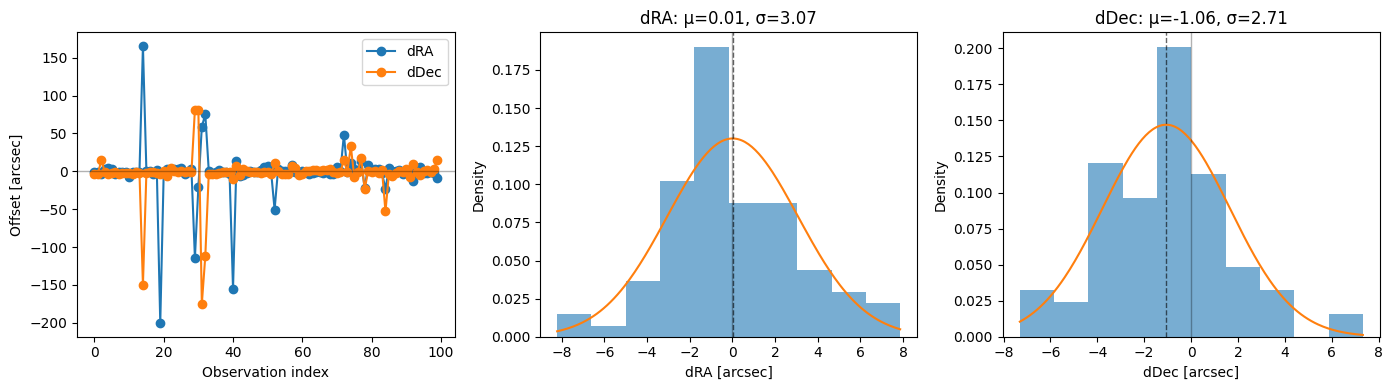

dRA  mean = 0.011 arcsec
dRA  std  = 3.068 arcsec
dDec mean = -1.062 arcsec
dDec std  = 2.714 arcsec
dRA  clipped 15 / 100 points
dDec clipped 15 / 100 points


In [146]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(t, dra, marker="o", label="dRA")
ax.plot(t, ddec, marker="o", label="dDec")
ax.axhline(0, color="k", lw=1, alpha=0.3)
ax.set_xlabel("Observation index")
ax.set_ylabel("Offset [arcsec]")
ax.legend()

clip = 3.0

dra_med = np.median(dra)
dra_sig = 1.4826 * np.median(np.abs(dra - dra_med))
dra_clip = dra[np.abs(dra - dra_med) < clip * dra_sig]

ddec_med = np.median(ddec)
ddec_sig = 1.4826 * np.median(np.abs(ddec - ddec_med))
ddec_clip = ddec[np.abs(ddec - ddec_med) < clip * ddec_sig]

dra_mu, dra_std = norm.fit(dra_clip)
ddec_mu, ddec_std = norm.fit(ddec_clip)

axes[1].hist(dra_clip, bins=10, density=True, alpha=0.6)
x = np.linspace(np.min(dra_clip), np.max(dra_clip), 200)
axes[1].plot(x, norm.pdf(x, dra_mu, dra_std))
axes[1].axvline(0, color="k", lw=1, alpha=0.3)
axes[1].axvline(dra_mu, color="k", lw=1, ls="--", alpha=0.6)
axes[1].set_xlabel("dRA [arcsec]")
axes[1].set_ylabel("Density")
axes[1].set_title(f"dRA: μ={dra_mu:.2f}, σ={dra_std:.2f}")

axes[2].hist(ddec_clip, bins=10, density=True, alpha=0.6)
x = np.linspace(np.min(ddec_clip), np.max(ddec_clip), 200)
axes[2].plot(x, norm.pdf(x, ddec_mu, ddec_std))
axes[2].axvline(0, color="k", lw=1, alpha=0.3)
axes[2].axvline(ddec_mu, color="k", lw=1, ls="--", alpha=0.6)
axes[2].set_xlabel("dDec [arcsec]")
axes[2].set_ylabel("Density")
axes[2].set_title(f"dDec: μ={ddec_mu:.2f}, σ={ddec_std:.2f}")

plt.tight_layout()
plt.show()

print(f"dRA  mean = {dra_mu:.3f} arcsec")
print(f"dRA  std  = {dra_std:.3f} arcsec")
print(f"dDec mean = {ddec_mu:.3f} arcsec")
print(f"dDec std  = {ddec_std:.3f} arcsec")

print(f"dRA  clipped {len(dra) - len(dra_clip)} / {len(dra)} points")
print(f"dDec clipped {len(ddec) - len(ddec_clip)} / {len(ddec)} points")

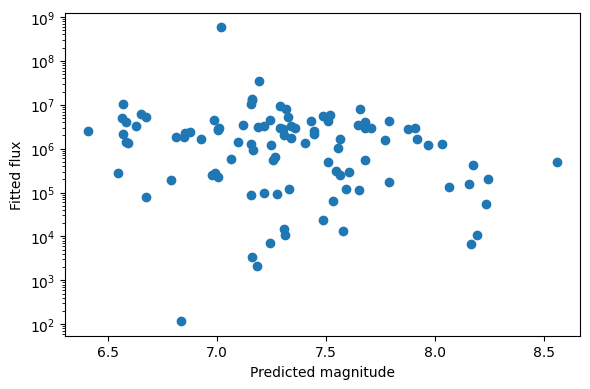

In [147]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(pred_mag, fit_flux)
ax.set_yscale("log")

ax.set_xlabel("Predicted magnitude")
ax.set_ylabel("Fitted flux")

plt.tight_layout()
plt.show()